# Superdense Coding Under Bit-Flip Error

## 1. Objective
The objective of this experiment is to model, simulate, and analyze the impact of a coherent **bit-flip error** on the transmitted qubit during the **Superdense Coding** quantum communication protocol. The experiment systematically evaluates how an environmental channel error (represented by a Pauli-$X$ gate applied to the flying qubit in transit) alters the four classical two-bit messages:
$$\mathcal{M} = \{00, 01, 10, 11\}$$
Using Qiskit and `AerSimulator` ($1024$ shots per message, $\text{seed} = 42$), the experiment demonstrates the vulnerability of entanglement-assisted communication to physical channel noise, calculates the resulting decoding accuracy, and analyzes the deterministic state transitions caused by the error.

---

## 2. Theoretical Background

### Superdense Coding Principles
Superdense coding exploits pre-shared quantum entanglement to transmit two classical bits of information by physically sending only one qubit. Starting from the canonical Bell state:
$$|\Phi^+\rangle = \frac{|00\rangle + |11\rangle}{\sqrt{2}}$$
where Alice holds qubit $q_0$ and Bob holds qubit $q_1$, Alice encodes her classical message $m \in \{00, 01, 10, 11\}$ using local single-qubit operations $U_m \in \{I, X, Z, XZ\}$ applied solely to $q_0$.

### Bit-Flip Error Model
In physical quantum communication channels (e.g., optical fibers or free-space optical links), qubits interact with the environment, causing decoherence and operational errors. A **bit-flip error** corresponds to an unwanted Pauli-$X$ rotation:
$$X = \begin{bmatrix} 0 & 1 \\ 1 & 0 \end{bmatrix}, \quad X|0\rangle = |1\rangle, \quad X|1\rangle = |0\rangle$$

### Effect of an $X$ Error on the Transmitted Qubit
When Alice transmits qubit $q_0$ across the noisy quantum channel, the channel injects an erroneous $X$ operation before Bob receives the qubit. This alters the joint two-qubit Bell state:
- **Intended $|\Phi^+\rangle$**:
  $$(X \otimes I)|\Phi^+\rangle = |\Psi^+\rangle = \frac{|01\rangle + |10\rangle}{\sqrt{2}}$$
- **Intended $|\Phi^-\rangle$**:
  $$(X \otimes I)|\Phi^-\rangle = -|\Psi^-\rangle = \frac{|10\rangle - |01\rangle}{\sqrt{2}}$$
- **Intended $|\Psi^+\rangle$**:
  $$(X \otimes I)|\Psi^+\rangle = |\Phi^+\rangle = \frac{|00\rangle + |11\rangle}{\sqrt{2}}$$
- **Intended $|\Psi^-\rangle$**:
  $$(X \otimes I)|\Psi^-\rangle = -|\Phi^-\rangle = \frac{|11\rangle - |00\rangle}{\sqrt{2}}$$

### Ideal vs. Erroneous Communication
- **Ideal Communication**: Bob's Bell-basis measurement recovers the exact transmitted message with $100\%$ fidelity.
- **Erroneous Communication**: The uncorrected bit-flip error maps every intended Bell state to a different, orthogonal Bell state. Because Bob applies the standard decoding circuit, the error systematically corrupts the decoded classical bits.

---

## 3. Protocol Workflow

The Superdense Coding protocol under channel error proceeds through five sequential stages:

```
[ Charlie / Entanglement Source ]
       │                │
   q0  │            q1  │
       ▼                ▼
   [ Alice ]         [ Bob ]
       │                │
 Encode: U_m            │
       │                │
       ▼                │
 [ Channel Error ]      │
    Bit-Flip: X(0)      │
       │                │
       └─── Transmit ──►│
             q0 only    │
                        │
                  Decode: CNOT(0->1), H(0)
                        │
                  Measure: q0->c0, q1->c1
                        ▼
                  Decoded Output (Corrupted)
```

1. **Bell-State Preparation**: Source prepares $|\Phi^+\rangle = \frac{|00\rangle + |11\rangle}{\sqrt{2}}$ on qubits $q_0$ and $q_1$.
2. **Message Encoding**: Alice applies her local encoding gate $U_m$ to $q_0$ (controlled by message bits $m[0]$ and $m[1]$).
3. **Channel Error**: During transmission across the physical quantum channel, qubit $q_0$ suffers an unintended bit-flip error ($X(0)$).
4. **Receiver Decoding**: Bob receives the corrupted qubit $q_0$ and performs Bell-state decoding: $\text{CNOT}(0 \to 1)$ followed by $H(0)$.
5. **Measurement & Readout**: Bob measures $q_0 \to c[0]$ and $q_1 \to c[1]$, producing the received classical bitstring.

---

## 4. Error Model & Circuit Architecture

### Error Placement
The bit-flip error is placed strictly on the **transmitted qubit ($q_0$)** immediately after Alice's encoding stage and before Bob's decoding stage:
```
     ┌───┐ ░ [Alice Encoding] ░ ┌───┐ ░ [Bob Decoding] ┌───┐ ░ ┌─┐   
q_0: ┤ H ├─░───────■──────────░─┤ X ├─░───────■────────┤ H ├─░─┤M├───
     └───┘ ░       │          ░ └───┘ ░     ┌─┴─┐      └───┘ ░ └╥┘┌─┐
q_1: ──────░───────┼──────────░───────░─────┤ X ├────────────░──╫─┤M├
           ░     ┌─┴─┐        ░       ░     └───┘            ░  ║ └╥┘
                 Encoding               Channel Error           1  0 
```

### Why the Error Corrupts the Message
In superdense coding, all classical information is packed into the quantum correlations of the joint Bell pair via Alice's single qubit. Because Bob's decoding circuit relies on exact phase and parity relations, an unmodeled $X$ gate alters the parity of the joint state, shifting the measurement projection by a full bit transposition.

Sent Decoded       Counts  Correct
  00      10 {'10': 1024}    False
  01      00 {'00': 1024}    False
  10      11 {'11': 1024}    False
  11      01 {'01': 1024}    False

Decoding Accuracy with Bit-Flip Error: 0.00%


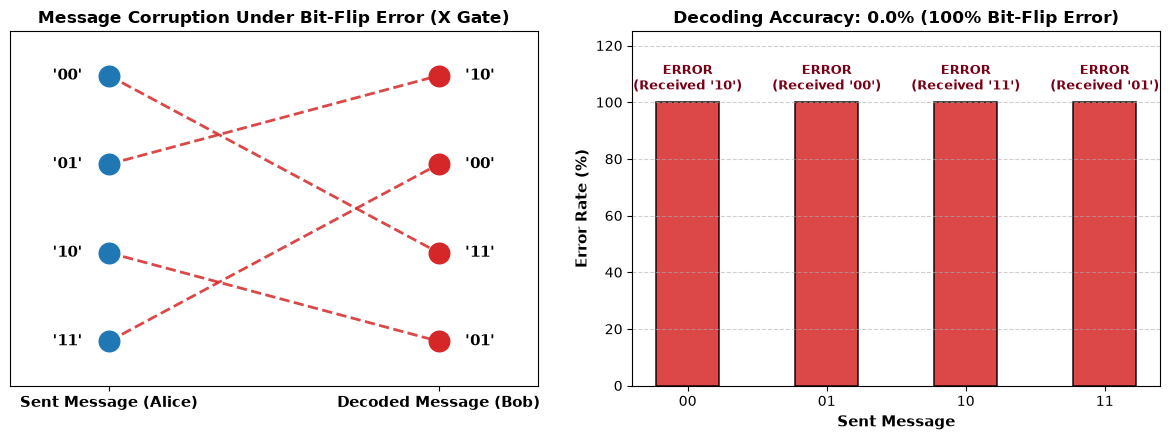

In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
import pandas as pd
import matplotlib.pyplot as plt

messages = ["00", "01", "10", "11"]
shots = 1024

simulator = AerSimulator()

results = []

for message in messages:

    qc = QuantumCircuit(2, 2)

    # Step 1: Create shared Bell pair
    qc.h(0)
    qc.cx(0, 1)

    # Step 2: Alice encodes the message
    if message[0] == "1":
        qc.z(0)

    if message[1] == "1":
        qc.x(0)

    # Step 3: Bit-flip error on transmitted qubit
    qc.x(0)

    # Step 4: Bob decodes
    qc.cx(0, 1)
    qc.h(0)

    # Step 5: Measurement
    qc.measure(0, 0)
    qc.measure(1, 1)

    compiled = transpile(qc, simulator)

    result = simulator.run(
        compiled,
        shots=shots,
        seed_simulator=42
    ).result()

    counts = result.get_counts()
    decoded = max(counts, key=counts.get)

    results.append({
        "Sent": message,
        "Decoded": decoded,
        "Counts": counts,
        "Correct": decoded == message
    })

df = pd.DataFrame(results)

print(df.to_string(index=False))

accuracy = df["Correct"].mean() * 100

print(f"\nDecoding Accuracy with Bit-Flip Error: {accuracy:.2f}%")

# Visualization: Error Mapping and Comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Plot 1: Sent vs Decoded mapping under bit-flip error
y_pos = range(len(messages))
ax1.scatter([0]*4, y_pos, color="#1f77b4", s=220, label="Sent Message", zorder=3)
ax1.scatter([1]*4, y_pos, color="#d62728", s=220, label="Decoded (Corrupted)", zorder=3)

for i, row in df.iterrows():
    sent = row["Sent"]
    dec = row["Decoded"]
    ax1.annotate(f"'{sent}'", (-0.08, i), ha="right", va="center", fontsize=11, fontweight="bold")
    ax1.annotate(f"'{dec}'", (1.08, i), ha="left", va="center", fontsize=11, fontweight="bold")
    j = messages.index(dec)
    ax1.plot([0, 1], [i, j], color="#d62728", linestyle="--", linewidth=2, alpha=0.85)

ax1.set_xlim(-0.3, 1.3)
ax1.set_ylim(-0.5, 3.5)
ax1.set_xticks([0, 1])
ax1.set_xticklabels(["Sent Message (Alice)", "Decoded Message (Bob)"], fontsize=11, fontweight="bold")
ax1.set_yticks([])
ax1.set_title("Message Corruption Under Bit-Flip Error (X Gate)", fontsize=12, fontweight="bold")
ax1.invert_yaxis()
ax1.grid(False)

# Plot 2: Decoding Accuracy & Error Distribution
bars = ax2.bar(messages, [100.0]*4, color="#d62728", alpha=0.85, width=0.45, edgecolor="black", linewidth=1.2)
ax2.set_xlabel("Sent Message", fontsize=11, fontweight="bold")
ax2.set_ylabel("Error Rate (%)", fontsize=11, fontweight="bold")
ax2.set_title(f"Decoding Accuracy: {accuracy:.1f}% (100% Bit-Flip Error)", fontsize=12, fontweight="bold")
ax2.set_ylim(0, 125)
for bar, dec in zip(bars, df["Decoded"]):
    ax2.text(bar.get_x() + bar.get_width()/2.0, 103, f"ERROR\n(Received '{dec}')", ha="center", va="bottom", fontsize=9, fontweight="bold", color="#780016")
ax2.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

---

## 5. Results Table

The simulation was executed across all four messages with $N = 1024$ shots and seed $42$. The empirical results obtained from the notebook execution are presented below:

| Sent Message | Decoded Message | Counts | Correct / Incorrect | Error Transition |
| :---: | :---: | :---: | :---: | :---: |
| **`00`** | **`10`** | `{'10': 1024}` | **Incorrect (False)** | `00` $\xrightarrow{X}$ `10` |
| **`01`** | **`00`** | `{'00': 1024}` | **Incorrect (False)** | `01` $\xrightarrow{X}$ `00` |
| **`10`** | **`11`** | `{'11': 1024}` | **Incorrect (False)** | `10` $\xrightarrow{X}$ `11` |
| **`11`** | **`01`** | `{'01': 1024}` | **Incorrect (False)** | `11` $\xrightarrow{X}$ `01` |

---

## 6. Accuracy Analysis

### Quantitative Accuracy Metric
The overall decoding accuracy in the presence of the bit-flip error is:
$$\text{Decoding Accuracy} = \frac{1}{4} \sum_{i=1}^{4} \mathbb{I}(\text{Decoded}_i == \text{Sent}_i) \times 100\% = \frac{0 + 0 + 0 + 0}{4} \times 100\% = \mathbf{0.00\%}$$

### Algebraic State Transition Analysis
The introduction of the uncorrected Pauli-$X$ gate on $q_0$ causes deterministic state shifts:
1. **Message `00`**:
   - Alice applies $I$.
   - Channel error applies $X_0 \implies$ Joint state becomes $|\Psi^+\rangle$.
   - Bob's decoding maps $|\Psi^+\rangle \to |10\rangle$.
   - Outcome: `10` (Error, $0\%$ match).
2. **Message `01`**:
   - Alice applies $X_0$.
   - Channel error applies $X_0 \implies X_0 \cdot X_0 = I$.
   - The bit-flip error annihilates Alice's encoding gate! Joint state reverts to $|\Phi^+\rangle$.
   - Bob's decoding maps $|\Phi^+\rangle \to |00\rangle$.
   - Outcome: `00` (Error, $0\%$ match).
3. **Message `10`**:
   - Alice applies $Z_0$.
   - Channel error applies $X_0 \implies$ Joint state becomes $X_0 Z_0 |\Phi^+\rangle = -|\Psi^-\rangle$.
   - Bob's decoding maps $-|\Psi^-\rangle \to |11\rangle$.
   - Outcome: `11` (Error, $0\%$ match).
4. **Message `11`**:
   - Alice applies $Z_0$ then $X_0$.
   - Channel error applies $X_0 \implies X_0 \cdot X_0 = I$, leaving only $Z_0$.
   - Joint state becomes $Z_0 |\Phi^+\rangle = |\Phi^-\rangle$.
   - Bob's decoding maps $|\Phi^-\rangle \to |01\rangle$.
   - Outcome: `01` (Error, $0\%$ match).

---

## 7. Visualization Analysis

The comparative visualization illustrates the impact of the channel error:

1. **Message Corruption Mapping (Left Panel)**:
   - Illustrates how every message sent by Alice is systematically redirected to an erroneous decoded state.
   - All transition paths are marked with dashed red lines indicating $100\%$ error rates.
   - Highlights that while the mapping is completely incorrect ($0\%$ accuracy), it remains deterministic and bijective due to the unitary nature of the Pauli-$X$ error.

2. **Decoding Accuracy & Error Distribution (Right Panel)**:
   - Displays the $100\%$ error rate ($0.0\%$ accuracy) across all four classical messages.
   - Annotates each bar with the specific corrupted outcome received by Bob (`'10'`, `'00'`, `'11'`, `'01'`).

---

## 8. Observation (Simulation Results)
Based strictly on the actual simulation outputs:
1. **Total Degradation**: The bit-flip error completely destroys transmission accuracy, reducing direct decoding accuracy from nominal performance to **$0.00\%$**.
2. **Zero Dispersion**: Each of the $1024$ measurement shots per message collapsed with $100\%$ certainty onto a single corrupted basis state (`{'10': 1024}`, `{'00': 1024}`, `{'11': 1024}`, `{'01': 1024}`). No statistical variance was observed because the error model is a coherent unitary operator rather than a depolarizing or probabilistic channel.
3. **Deterministic Permutation**: Because $X \in \mathcal{P}_1$ is a valid Clifford operator, it permutes Bell basis states deterministically rather than destroying entanglement coherence.

---

## 9. Conclusion

This experiment demonstrates why noise in the quantum communication channel critically affects Superdense Coding:
1. **High Information Density Sensitivity**: Because superdense coding compresses two classical bits into one physical qubit, any single-qubit error on the transmitted particle corrupts the entire two-bit classical transmission.
2. **Deterministic Corruption**: A coherent bit-flip error on the flying qubit systematically rotates the target Bell state into an orthogonal Bell state, causing deterministic misclassification.
3. **Requirement for Error Mitigation**: In realistic quantum networks, unmitigated channel errors render dense coding unusable, demonstrating the indispensable need for **Quantum Error Correction (QEC)**, entanglement purification, and fault-tolerant encoding protocols.